Check whether turning on/off dust has a big effect on the UVLF

In [22]:
from escripts import eMCMC
import importlib
from escripts import eplots
Plotting = eplots.Plotting()
import matplotlib.ticker as ticker

In [3]:
with_dust = np.loadtxt('/Users/eb35267/Desktop/code/home/data/z11-14.5_with_dust.txt', unpack = True)
without_dust = np.loadtxt('/Users/eb35267/Desktop/code/home/data/z11-14.5_without_dust.txt', unpack = True)

In [9]:
with_dust

array([[ 1.1000e+01,  1.1000e+01,  1.1000e+01,  1.1000e+01,  1.1000e+01,
         1.1000e+01,  1.1000e+01,  1.1000e+01,  1.1000e+01,  1.1000e+01,
         1.1000e+01,  1.1000e+01,  1.2500e+01,  1.2500e+01,  1.2500e+01,
         1.2500e+01,  1.2500e+01,  1.2500e+01,  1.2500e+01,  1.2500e+01,
         1.2500e+01,  1.2500e+01,  1.2500e+01,  1.2500e+01,  1.3500e+01,
         1.3500e+01,  1.3500e+01,  1.3500e+01,  1.3500e+01,  1.3500e+01,
         1.3500e+01,  1.3500e+01,  1.3500e+01,  1.3500e+01,  1.3500e+01,
         1.3500e+01,  1.4500e+01,  1.4500e+01,  1.4500e+01,  1.4500e+01,
         1.4500e+01,  1.4500e+01,  1.4500e+01,  1.4500e+01,  1.4500e+01,
         1.4500e+01,  1.4500e+01,  1.4500e+01],
       [-2.2690e+01, -2.2190e+01, -2.1690e+01, -2.1190e+01, -2.0690e+01,
        -2.0190e+01, -1.9690e+01, -1.9190e+01, -1.8690e+01, -1.7940e+01,
        -1.6940e+01, -1.5940e+01, -2.2690e+01, -2.2190e+01, -2.1690e+01,
        -2.1190e+01, -2.0690e+01, -2.0190e+01, -1.9690e+01, -1.9190e+01,
   

In [4]:
redshifts = np.unique(with_dust[0])

<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_66050/335657780.py:14: SyntaxWarning: invalid escape sequence '\s'
  ax[i].set_title(f'$z \simeq {round(z, 2)}$')


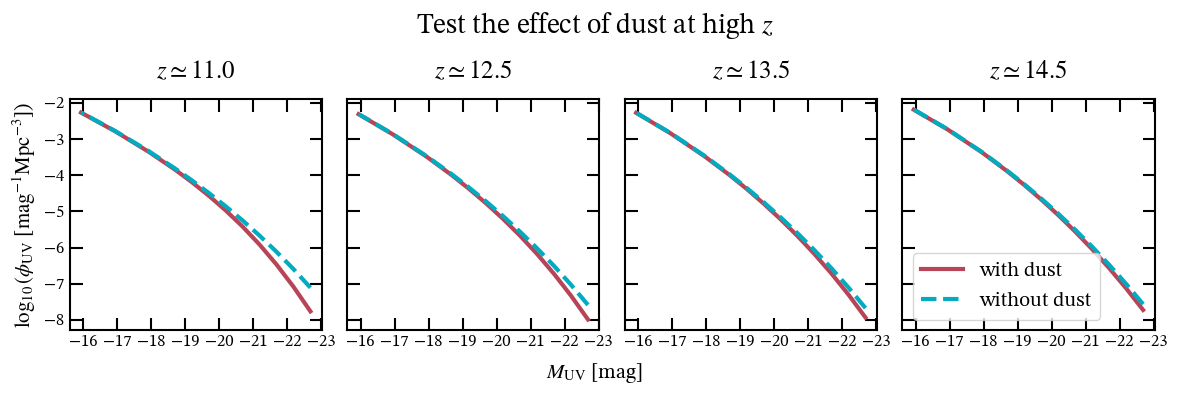

In [25]:
fig, ax = plt.subplots(1, len(redshifts), sharey = True)
fig.set_size_inches(3.5*len(redshifts), 3)
plt.subplots_adjust(wspace = 0.1)

for i, z in enumerate(redshifts):
    for dataset, color, label, ls in zip([with_dust, without_dust], [Plotting.red, Plotting.turquoise], ['with dust', 'without dust'], 
                                         ['-', 'dashed']):
        inds = np.where(dataset[0] == z)[0]
        plot_x = dataset[1][inds]
        plot_y = dataset[3][inds]
        ax[i].plot(plot_x, np.log10(plot_y), color = color, linestyle = ls, label = label)
                
    ax[i].invert_xaxis()
    ax[i].set_title(f'$z \simeq {round(z, 2)}$')
    ax[i].xaxis.set_major_locator(ticker.MaxNLocator(integer=True)) # Make it so that only integers can be used in the  
                                                                                   # axis labels

ax[0].set_ylabel(r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])')
fig.text(.5, -0.05, r'$M_{\rm{UV}}$ [mag]', ha = 'center')
fig.text(.5, 1.1, r'Test the effect of dust at high $z$', ha = 'center', fontsize = 20)
ax[-1].legend()

In [26]:
fig.savefig('/Users/eb35267/Desktop/code/figures/Gelli_comparison/effect_of_dust.png', bbox_inches='tight')